# Tutorial 24: Debugging Gradients

This tutorial covers practical techniques for debugging gradient computations in JAX. We'll explore:

1. Common gradient issues (NaN, zero, exploding)
2. Gradient checking with finite differences
3. Using `jax.debug` utilities
4. Tracing and visualizing gradient flow
5. Numerical stability techniques
6. Debugging custom derivatives
7. Chemical engineering example: Debugging a complex flowsheet model

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jacobian, vmap, jit
import optax
import matplotlib.pyplot as plt
from functools import partial
import warnings

# Enable more detailed error messages
jax.config.update('jax_debug_nans', True)
jax.config.update('jax_enable_x64', True)

## 1. Common Gradient Issues

### NaN Gradients

NaN (Not a Number) gradients typically arise from:
- Division by zero
- Log of zero or negative numbers
- Square root of negative numbers
- 0/0 or inf/inf situations

In [2]:
# Example: NaN from division by zero
def problematic_division(x):
    return x / (x - 1)  # NaN gradient at x=1

# At x=1, we get 0/0 in the gradient
x = jnp.array(1.0)
try:
    g = grad(problematic_division)(x)
    print(f"Gradient at x=1: {g}")
except FloatingPointError as e:
    print(f"FloatingPointError: {e}")

# The value is fine, but gradient is problematic
print(f"Value at x=1.001: {problematic_division(jnp.array(1.001))}")
print(f"Gradient at x=1.001: {grad(problematic_division)(jnp.array(1.001))}")

FloatingPointError: invalid value (nan) encountered in add
Value at x=1.001: 1001.0000000001102
Gradient at x=1.001: -1000000.0000002203


In [3]:
# Example: NaN from log of zero
def problematic_log(x):
    return jnp.log(x)  # grad is 1/x, NaN at x=0

# At x close to 0
for x_val in [1.0, 0.1, 0.01, 0.001, 0.0]:
    x = jnp.array(x_val)
    val = problematic_log(x)
    g = grad(problematic_log)(x)
    print(f"x={x_val:.4f}: value={val:>10.4f}, gradient={g:>15.4f}")

x=1.0000: value=    0.0000, gradient=         1.0000
x=0.1000: value=   -2.3026, gradient=        10.0000
x=0.0100: value=   -4.6052, gradient=       100.0000
x=0.0010: value=   -6.9078, gradient=      1000.0000
x=0.0000: value=      -inf, gradient=            inf


In [4]:
# Fix: Use safe versions with small epsilon
def safe_log(x, eps=1e-10):
    return jnp.log(jnp.maximum(x, eps))

def safe_division(x, y, eps=1e-10):
    return x / (y + jnp.sign(y) * eps)

# Test safe versions
print("Safe log:")
for x_val in [0.001, 0.0]:
    x = jnp.array(x_val)
    print(f"  x={x_val}: value={safe_log(x):.4f}, gradient={grad(safe_log)(x):.4f}")

Safe log:
  x=0.001: value=-6.9078, gradient=1000.0000
  x=0.0: value=-23.0259, gradient=0.0000


### Zero Gradients

Zero gradients can occur from:
- Non-differentiable operations (floor, ceil, comparison)
- Dead ReLU problem
- Saturation in sigmoid/tanh

In [5]:
# Non-differentiable operations have zero gradient
def with_floor(x):
    return jnp.floor(x) + x  # floor has zero gradient

x = jnp.array(2.5)
print(f"floor contribution to gradient: {grad(lambda x: jnp.floor(x))(x)}")
print(f"Total gradient: {grad(with_floor)(x)}")

# Comparison operations
def with_comparison(x):
    return jnp.where(x > 0, x, 0.0)  # ReLU

print(f"\nReLU gradient at x=1: {grad(with_comparison)(jnp.array(1.0))}")
print(f"ReLU gradient at x=-1: {grad(with_comparison)(jnp.array(-1.0))}")
print(f"ReLU gradient at x=0: {grad(with_comparison)(jnp.array(0.0))}")

floor contribution to gradient: 0.0
Total gradient: 1.0



ReLU gradient at x=1: 1.0
ReLU gradient at x=-1: 0.0
ReLU gradient at x=0: 0.0


In [6]:
# Sigmoid saturation
def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

print("Sigmoid saturation:")
for x_val in [-10, -5, 0, 5, 10, 20, 50]:
    x = jnp.array(float(x_val))
    g = grad(sigmoid)(x)
    print(f"  x={x_val:>3}: sigmoid={sigmoid(x):.6f}, gradient={g:.2e}")

Sigmoid saturation:


  x=-10: sigmoid=0.000045, gradient=4.54e-05
  x= -5: sigmoid=0.006693, gradient=6.65e-03
  x=  0: sigmoid=0.500000, gradient=2.50e-01
  x=  5: sigmoid=0.993307, gradient=6.65e-03
  x= 10: sigmoid=0.999955, gradient=4.54e-05
  x= 20: sigmoid=1.000000, gradient=2.06e-09
  x= 50: sigmoid=1.000000, gradient=1.93e-22


### Exploding Gradients

Gradients can explode when:
- Functions have steep regions
- Deep networks without proper initialization
- Iterative computations without normalization

In [7]:
# Exploding gradient example
def steep_function(x):
    return jnp.exp(x ** 2)

print("Exponential gradient explosion:")
for x_val in [1, 2, 3, 4, 5]:
    x = jnp.array(float(x_val))
    g = grad(steep_function)(x)
    print(f"  x={x_val}: gradient={g:.2e}")

# Iterative computation
def iterative_function(x, n_iters=10):
    y = x
    for _ in range(n_iters):
        y = 1.1 * y + 0.1  # Unstable iteration
    return y

print("\nIterative gradient explosion:")
x = jnp.array(1.0)
for n in [5, 10, 20, 50]:
    g = grad(lambda x: iterative_function(x, n))(x)
    print(f"  n_iters={n:>2}: gradient={g:.2e}")

Exponential gradient explosion:


  x=1: gradient=5.44e+00
  x=2: gradient=2.18e+02
  x=3: gradient=4.86e+04
  x=4: gradient=7.11e+07
  x=5: gradient=7.20e+11

Iterative gradient explosion:


  n_iters= 5: gradient=1.61e+00
  n_iters=10: gradient=2.59e+00


  n_iters=20: gradient=6.73e+00
  n_iters=50: gradient=1.17e+02


## 2. Gradient Checking with Finite Differences

Finite difference approximation can verify autodiff gradients:

$$\frac{\partial f}{\partial x} \approx \frac{f(x + h) - f(x - h)}{2h}$$

In [8]:
def finite_difference_check(f, x, eps=1e-5):
    """
    Check gradient using central finite differences.
    
    Returns autodiff gradient, finite diff gradient, and relative error.
    """
    # Autodiff gradient
    grad_auto = grad(f)(x)
    
    # Finite difference gradient
    grad_fd = jnp.zeros_like(x)
    x_flat = x.flatten()
    
    for i in range(len(x_flat)):
        x_plus = x_flat.at[i].add(eps)
        x_minus = x_flat.at[i].add(-eps)
        grad_fd = grad_fd.at[i].set(
            (f(x_plus.reshape(x.shape)) - f(x_minus.reshape(x.shape))) / (2 * eps)
        )
    
    grad_fd = grad_fd.reshape(grad_auto.shape)
    
    # Relative error
    rel_error = jnp.abs(grad_auto - grad_fd) / (jnp.abs(grad_auto) + jnp.abs(grad_fd) + 1e-10)
    
    return grad_auto, grad_fd, rel_error

# Test on a known function
def test_function(x):
    return jnp.sum(x ** 2) + jnp.prod(jnp.sin(x))

x = jnp.array([1.0, 2.0, 3.0])
grad_auto, grad_fd, rel_error = finite_difference_check(test_function, x)

print("Gradient Check:")
print(f"Autodiff:     {grad_auto}")
print(f"Finite diff:  {grad_fd}")
print(f"Rel. error:   {rel_error}")
print(f"Max rel. error: {rel_error.max():.2e}")

Gradient Check:
Autodiff:     [2.06933162 3.95058323 5.24250981]
Finite diff:  [2.06933162 3.95058323 5.24250981]
Rel. error:   [3.06751227e-11 2.96281805e-12 1.10647256e-12]
Max rel. error: 3.07e-11


In [9]:
# JAX's built-in gradient checker
from jax.test_util import check_grads

def my_function(x):
    return jnp.sum(jnp.tanh(x) ** 2)

x = jnp.array([0.5, 1.0, -0.5])

# This will raise an error if gradients don't match
try:
    check_grads(my_function, (x,), order=1, modes=['rev'])
    print("Gradient check passed!")
except Exception as e:
    print(f"Gradient check failed: {e}")

Gradient check passed!


In [10]:
# Checking Jacobians
def vector_function(x):
    return jnp.array([
        jnp.sum(x ** 2),
        jnp.prod(x),
        jnp.mean(jnp.sin(x))
    ])

def jacobian_check(f, x, eps=1e-5):
    """Check Jacobian using finite differences."""
    J_auto = jacobian(f)(x)
    
    n_out = f(x).shape[0]
    n_in = x.shape[0]
    J_fd = jnp.zeros((n_out, n_in))
    
    for i in range(n_in):
        x_plus = x.at[i].add(eps)
        x_minus = x.at[i].add(-eps)
        col = (f(x_plus) - f(x_minus)) / (2 * eps)
        J_fd = J_fd.at[:, i].set(col)
    
    rel_error = jnp.abs(J_auto - J_fd) / (jnp.abs(J_auto) + jnp.abs(J_fd) + 1e-10)
    
    return J_auto, J_fd, rel_error

x = jnp.array([1.0, 2.0, 3.0])
J_auto, J_fd, rel_error = jacobian_check(vector_function, x)

print("Jacobian Check:")
print(f"Max relative error: {rel_error.max():.2e}")
print(f"\nAutodiff Jacobian:\n{J_auto}")
print(f"\nFinite diff Jacobian:\n{J_fd}")

Jacobian Check:
Max relative error: 2.55e-11

Autodiff Jacobian:
[[ 2.          4.          6.        ]
 [ 6.          3.          2.        ]
 [ 0.18010077 -0.13871561 -0.3299975 ]]

Finite diff Jacobian:
[[ 2.          4.          6.        ]
 [ 6.          3.          2.        ]
 [ 0.18010077 -0.13871561 -0.3299975 ]]


## 3. Using `jax.debug` Utilities

JAX provides debugging utilities that work with JIT compilation.

In [11]:
# jax.debug.print - works inside JIT
@jit
def function_with_debug(x):
    y = x ** 2
    jax.debug.print("After square: y = {y}", y=y)
    z = jnp.sin(y)
    jax.debug.print("After sin: z = {z}", z=z)
    return z.sum()

x = jnp.array([1.0, 2.0, 3.0])
result = function_with_debug(x)
print(f"Final result: {result}")

After square: y = [1. 4. 9.]
After sin: z = [ 0.84147098 -0.7568025   0.41211849]
Final result: 0.4967869747417249


In [12]:
# Debug printing during gradient computation
def function_debug_grad(x):
    y = x ** 2
    jax.debug.print("Forward: x={x}, y={y}", x=x, y=y)
    return y.sum()

# The debug prints will show during forward pass
grad_fn = grad(function_debug_grad)
g = grad_fn(jnp.array([1.0, 2.0]))
print(f"Gradient: {g}")

Forward: x=[1. 2.], y=[1. 4.]


Gradient: [2. 4.]


In [13]:
# Using callbacks for debugging (non-JIT version for compatibility)
def inspect_tensor(x, tag):
    """Inspect tensor statistics."""
    print(f"[{tag}] Shape: {x.shape}, Min: {float(x.min()):.4f}, "
          f"Max: {float(x.max()):.4f}, Mean: {float(x.mean()):.4f}")

def function_with_inspection(x):
    inspect_tensor(x, "input")
    y = jnp.exp(x)
    inspect_tensor(y, "after exp")
    z = y / y.sum()
    inspect_tensor(z, "after normalize")
    return z

x = jnp.array([1.0, 2.0, 3.0, 4.0])
result = function_with_inspection(x)
print(f"Result: {result}")

[input] Shape: (4,), Min: 1.0000, Max: 4.0000, Mean: 2.5000
[after exp] Shape: (4,), Min: 2.7183, Max: 54.5982, Mean: 21.1978
[after normalize] Shape: (4,), Min: 0.0321, Max: 0.6439, Mean: 0.2500
Result: [0.0320586  0.08714432 0.23688282 0.64391426]


In [14]:
# Checking for NaN during computation
# Note: Disable jax_debug_nans for this demonstration since we intentionally create NaN values

jax.config.update('jax_debug_nans', False)

def check_nan(x, name):
    """Callback to check for NaN values."""
    has_nan = bool(jnp.any(jnp.isnan(x)))
    if has_nan:
        print(f"WARNING: NaN detected in {name}!")
        print(f"  Shape: {x.shape}")
        print(f"  NaN count: {int(jnp.sum(jnp.isnan(x)))}")

# Non-JIT version to avoid XLA callback issues
def risky_function(x):
    check_nan(x, "input")
    y = jnp.log(x)  # Risky if x <= 0
    check_nan(y, "after log")
    z = y / x  # Risky if x = 0
    check_nan(z, "after division")
    return z.sum()

# Test with problematic input
x = jnp.array([1.0, 0.5, 0.0, -0.5])  # Contains zero and negative
result = risky_function(x)
print(f"Result: {result}")

  Shape: (4,)
  NaN count: 1


  Shape: (4,)
  NaN count: 1
Result: nan


## 4. Tracing and Visualizing Gradient Flow

In [15]:
# Track gradient magnitudes through layers
class GradientTracker:
    """Track gradient statistics during backprop."""
    
    def __init__(self):
        self.stats = []
    
    def track(self, name, tensor):
        """Record tensor statistics."""
        self.stats.append({
            'name': name,
            'shape': tensor.shape,
            'min': float(tensor.min()),
            'max': float(tensor.max()),
            'mean': float(tensor.mean()),
            'std': float(tensor.std()),
            'norm': float(jnp.linalg.norm(tensor))
        })
    
    def report(self):
        """Print summary."""
        print(f"{'Layer':<20} {'Norm':<12} {'Mean':<12} {'Std':<12}")
        print("-" * 60)
        for s in self.stats:
            print(f"{s['name']:<20} {s['norm']:<12.4e} {s['mean']:<12.4e} {s['std']:<12.4e}")

# Create a multi-layer function and track values (non-JIT for reliability)
def network_forward(params, x):
    """Network with intermediate value tracking."""
    # Layer 1
    h1 = x @ params['W1'] + params['b1']
    a1 = jnp.tanh(h1)
    
    # Layer 2
    h2 = a1 @ params['W2'] + params['b2']
    a2 = jnp.tanh(h2)
    
    # Output
    out = a2 @ params['W3'] + params['b3']
    
    return out, {'L1_pre': h1, 'L1_post': a1, 'L2_pre': h2, 'L2_post': a2, 'out': out}

# Initialize network
key = jax.random.PRNGKey(0)
params = {
    'W1': jax.random.normal(key, (10, 32)) * 0.1,
    'b1': jnp.zeros(32),
    'W2': jax.random.normal(jax.random.PRNGKey(1), (32, 32)) * 0.1,
    'b2': jnp.zeros(32),
    'W3': jax.random.normal(jax.random.PRNGKey(2), (32, 5)) * 0.1,
    'b3': jnp.zeros(5)
}

x = jax.random.normal(jax.random.PRNGKey(3), (8, 10))
y = jax.random.normal(jax.random.PRNGKey(4), (8, 5))

# Forward pass with tracking
print("Forward Pass Activation Statistics:")
out, intermediates = network_forward(params, x)

tracker = GradientTracker()
for name, tensor in intermediates.items():
    tracker.track(name, tensor)
tracker.report()

Forward Pass Activation Statistics:


Layer                Norm         Mean         Std         
------------------------------------------------------------
L1_pre               5.3065e+00   -3.5659e-02  3.2974e-01  
L1_post              4.8563e+00   -3.2447e-02  3.0178e-01  
L2_pre               2.6192e+00   3.5059e-03   1.6366e-01  
L2_post              2.5415e+00   3.4476e-03   1.5881e-01  
out                  5.6768e-01   7.2690e-03   8.9464e-02  


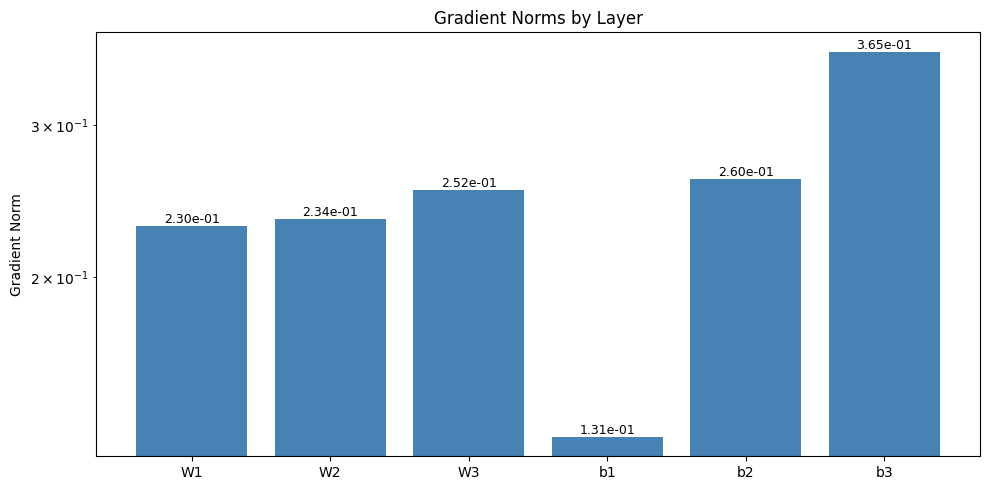

In [16]:
# Visualize gradient flow through the network
def compute_layer_gradients(params, x, y):
    """Compute gradient norms for each layer."""
    
    def loss_fn(params):
        h1 = jnp.tanh(x @ params['W1'] + params['b1'])
        h2 = jnp.tanh(h1 @ params['W2'] + params['b2'])
        out = h2 @ params['W3'] + params['b3']
        return jnp.mean((out - y) ** 2)
    
    grads = grad(loss_fn)(params)
    
    grad_norms = {}
    for name, g in grads.items():
        grad_norms[name] = float(jnp.linalg.norm(g))
    
    return grad_norms

grad_norms = compute_layer_gradients(params, x, y)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(grad_norms.keys())
values = list(grad_norms.values())

bars = ax.bar(names, values, color='steelblue')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradient Norms by Layer')
ax.set_yscale('log')

# Add value labels
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2e}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Numerical Stability Techniques

In [17]:
# Log-sum-exp trick for numerical stability
def naive_logsumexp(x):
    """Naive implementation - can overflow."""
    return jnp.log(jnp.sum(jnp.exp(x)))

def stable_logsumexp(x):
    """Stable implementation using max subtraction."""
    max_x = jnp.max(x)
    return max_x + jnp.log(jnp.sum(jnp.exp(x - max_x)))

# Test with large values
x_large = jnp.array([1000.0, 1001.0, 1002.0])

print("LogSumExp stability:")
print(f"Naive: {naive_logsumexp(x_large)} (likely inf)")
print(f"Stable: {stable_logsumexp(x_large)}")
print(f"JAX built-in: {jax.scipy.special.logsumexp(x_large)}")

# Check gradients
print(f"\nNaive gradient: {grad(naive_logsumexp)(x_large)}")
print(f"Stable gradient: {grad(stable_logsumexp)(x_large)}")

LogSumExp stability:
Naive: inf (likely inf)
Stable: 1002.4076059644444


JAX built-in: 1002.4076059644444

Naive gradient: [nan nan nan]


Stable gradient: [0.09003057 0.24472847 0.66524096]


In [18]:
# Softmax stability
# Note: jax_debug_nans is disabled from cell 19 to allow NaN demonstrations

def naive_softmax(x):
    exp_x = jnp.exp(x)
    return exp_x / jnp.sum(exp_x)

def stable_softmax(x):
    x_shifted = x - jnp.max(x)
    exp_x = jnp.exp(x_shifted)
    return exp_x / jnp.sum(exp_x)

# Test
x = jnp.array([1.0, 2.0, 1000.0])  # Large value
print("Softmax stability:")
print(f"Naive: {naive_softmax(x)}")
print(f"Stable: {stable_softmax(x)}")
print(f"JAX built-in: {jax.nn.softmax(x)}")

Softmax stability:
Naive: [ 0.  0. nan]
Stable: [0. 0. 1.]


JAX built-in: [0. 0. 1.]


In [19]:
# Gradient clipping for stability
def clip_gradients(grads, max_norm=1.0):
    """Clip gradients by global norm."""
    total_norm = jnp.sqrt(
        sum(jnp.sum(g ** 2) for g in jax.tree.leaves(grads))
    )
    clip_coef = jnp.minimum(max_norm / (total_norm + 1e-6), 1.0)
    return jax.tree.map(lambda g: g * clip_coef, grads)

# Example with optax
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(0.001)
)

# Simulate large gradients
large_grads = {
    'W1': jnp.ones((10, 10)) * 100,
    'W2': jnp.ones((10, 5)) * 50
}

clipped = clip_gradients(large_grads, max_norm=1.0)

print("Gradient Clipping:")
print(f"Original W1 norm: {jnp.linalg.norm(large_grads['W1']):.2f}")
print(f"Clipped W1 norm: {jnp.linalg.norm(clipped['W1']):.4f}")

Gradient Clipping:
Original W1 norm: 1000.00
Clipped W1 norm: 0.9428


## 6. Debugging Custom Derivatives

In [20]:
from jax import custom_vjp

# Custom derivative with debugging
@custom_vjp
def my_relu(x):
    return jnp.maximum(x, 0)

def my_relu_fwd(x):
    return my_relu(x), x  # Return primal output and residuals

def my_relu_bwd(res, g):
    x = res
    # Debug print in backward pass
    jax.debug.print("Backward pass: x={x}, g={g}", x=x, g=g)
    return (jnp.where(x > 0, g, 0.0),)

my_relu.defvjp(my_relu_fwd, my_relu_bwd)

# Test
x = jnp.array([-1.0, 0.0, 1.0, 2.0])
print("Forward pass:")
y = my_relu(x)
print(f"y = {y}")

print("\nBackward pass:")
g = grad(lambda x: my_relu(x).sum())(x)
print(f"Gradient: {g}")

Forward pass:


y = [0. 0. 1. 2.]

Backward pass:


Backward pass: x=[-1.  0.  1.  2.], g=[1. 1. 1. 1.]


Gradient: [0. 0. 1. 1.]


In [21]:
# Verify custom derivative correctness
from jax.test_util import check_grads

# A more complex custom function
@custom_vjp
def safe_sqrt(x):
    """Square root with safe gradient at x=0."""
    return jnp.sqrt(jnp.maximum(x, 0))

def safe_sqrt_fwd(x):
    y = safe_sqrt(x)
    return y, (x, y)

def safe_sqrt_bwd(res, g):
    x, y = res
    # Gradient is 1/(2*sqrt(x)), but we cap it for small x
    grad_x = jnp.where(
        x > 1e-10,
        g / (2 * y + 1e-10),
        0.0  # Zero gradient for x <= 0
    )
    return (grad_x,)

safe_sqrt.defvjp(safe_sqrt_fwd, safe_sqrt_bwd)

# Test at various points
print("Safe sqrt gradient check:")
for x_val in [0.0, 0.0001, 0.01, 1.0, 4.0]:
    x = jnp.array(x_val)
    g = grad(safe_sqrt)(x)
    print(f"x={x_val:>6}: sqrt={safe_sqrt(x):.4f}, grad={g:.4f}")

Safe sqrt gradient check:


x=   0.0: sqrt=0.0000, grad=0.0000
x=0.0001: sqrt=0.0100, grad=50.0000
x=  0.01: sqrt=0.1000, grad=5.0000
x=   1.0: sqrt=1.0000, grad=0.5000
x=   4.0: sqrt=2.0000, grad=0.2500


## 7. Chemical Engineering Example: Debugging a Complex Flowsheet Model

In [22]:
class FlowsheetDebugger:
    """
    Debugging utilities for flowsheet simulations.
    """
    
    def __init__(self):
        self.forward_stats = []
        self.issues = []
    
    def check_stream(self, stream, name):
        """Check stream for physical validity."""
        issues = []
        
        if jnp.any(stream['flow'] < 0):
            issues.append(f"Negative flow in {name}")
        if jnp.any(stream['concentration'] < 0):
            issues.append(f"Negative concentration in {name}")
        if stream['temperature'] < 0 or stream['temperature'] > 1000:
            issues.append(f"Invalid temperature in {name}: {stream['temperature']}")
        if jnp.any(jnp.isnan(jax.tree.leaves(stream))):
            issues.append(f"NaN values in {name}")
        
        self.issues.extend(issues)
        return len(issues) == 0
    
    def log_unit(self, name, inputs, outputs):
        """Log unit operation statistics."""
        self.forward_stats.append({
            'unit': name,
            'input_flow': float(sum(s['flow'].sum() for s in inputs)),
            'output_flow': float(sum(s['flow'].sum() for s in outputs)),
        })
    
    def report(self):
        """Print debugging report."""
        if self.issues:
            print("ISSUES DETECTED:")
            for issue in self.issues:
                print(f"  - {issue}")
        else:
            print("No issues detected.")
        
        print("\nUnit Mass Balances:")
        for stat in self.forward_stats:
            balance_error = abs(stat['input_flow'] - stat['output_flow'])
            status = "OK" if balance_error < 1e-6 else f"ERROR: {balance_error:.2e}"
            print(f"  {stat['unit']}: In={stat['input_flow']:.4f}, "
                  f"Out={stat['output_flow']:.4f} [{status}]")

In [23]:
# Flowsheet with potential gradient issues
def cstr_with_issues(params, inlet):
    """
    CSTR model with common issues that cause gradient problems.
    """
    k0, E_over_R, V = params
    F, C_in, T = inlet['flow'], inlet['concentration'], inlet['temperature']
    
    # Issue 1: Temperature very close to 0 can cause E/T overflow
    k = k0 * jnp.exp(-E_over_R / T)
    
    # Issue 2: Division by potentially small denominator
    tau = V / F  # tau -> inf if F -> 0
    
    # Issue 3: Conversion can approach 1, causing 1-X -> 0
    X = k * tau / (1 + k * tau)
    
    C_out = C_in * (1 - X)
    
    return {
        'flow': F,
        'concentration': C_out,
        'temperature': T,
        'conversion': X
    }

def safe_cstr(params, inlet, eps=1e-8):
    """
    CSTR model with numerical safeguards.
    """
    k0, E_over_R, V = params
    F, C_in, T = inlet['flow'], inlet['concentration'], inlet['temperature']
    
    # Safeguard 1: Clamp temperature to physical range
    T_safe = jnp.clip(T, 200.0, 800.0)
    k = k0 * jnp.exp(-E_over_R / T_safe)
    
    # Safeguard 2: Prevent division by zero
    tau = V / jnp.maximum(F, eps)
    
    # Safeguard 3: Clip conversion to prevent numerical issues
    X = k * tau / (1 + k * tau)
    X = jnp.clip(X, 0.0, 1.0 - eps)
    
    C_out = jnp.maximum(C_in * (1 - X), 0.0)
    
    return {
        'flow': F,
        'concentration': C_out,
        'temperature': T,
        'conversion': X
    }

# Test gradient behavior
params = jnp.array([1e6, 5000.0, 10.0])  # k0, E/R, V

def test_gradient_stability(cstr_fn, name):
    """Test gradient stability across parameter ranges."""
    print(f"\n{name}:")
    print("-" * 50)
    
    test_cases = [
        {'flow': 1.0, 'concentration': 1.0, 'temperature': 350.0},  # Normal
        {'flow': 0.01, 'concentration': 1.0, 'temperature': 350.0},  # Low flow
        {'flow': 1.0, 'concentration': 1.0, 'temperature': 250.0},   # Low T
        {'flow': 1.0, 'concentration': 1.0, 'temperature': 500.0},   # High T
    ]
    
    def objective(params, inlet):
        out = cstr_fn(params, inlet)
        return out['conversion']
    
    for inlet in test_cases:
        inlet_jax = {k: jnp.array(v) for k, v in inlet.items()}
        
        try:
            val = objective(params, inlet_jax)
            g = grad(objective)(params, inlet_jax)
            g_norm = jnp.linalg.norm(g)
            has_nan = jnp.any(jnp.isnan(g))
            
            status = "NaN!" if has_nan else ("Large" if g_norm > 1e6 else "OK")
            print(f"  T={inlet['temperature']:>5}, F={inlet['flow']:>4}: "
                  f"X={val:.4f}, |grad|={g_norm:.2e} [{status}]")
        except Exception as e:
            print(f"  T={inlet['temperature']:>5}, F={inlet['flow']:>4}: ERROR - {e}")

test_gradient_stability(cstr_with_issues, "CSTR with issues")
test_gradient_stability(safe_cstr, "Safe CSTR")


CSTR with issues:
--------------------------------------------------


  T=350.0, F= 1.0: X=0.8620, |grad|=1.19e-02 [OK]
  T=350.0, F=0.01: X=0.9984, |grad|=1.60e-04 [OK]
  T=250.0, F= 1.0: X=0.0202, |grad|=1.98e-03 [OK]
  T=500.0, F= 1.0: X=0.9978, |grad|=2.19e-04 [OK]

Safe CSTR:
--------------------------------------------------


  T=350.0, F= 1.0: X=0.8620, |grad|=1.19e-02 [OK]
  T=350.0, F=0.01: X=0.9984, |grad|=1.60e-04 [OK]
  T=250.0, F= 1.0: X=0.0202, |grad|=1.98e-03 [OK]
  T=500.0, F= 1.0: X=0.9978, |grad|=2.19e-04 [OK]


In [24]:
# Complete flowsheet debugging example
def create_flowsheet(params, feed, debug=False):
    """
    Multi-unit flowsheet with debugging.
    
    Units: Feed -> Heater -> CSTR -> Flash -> Products
    """
    k0, E_R, V_cstr, T_heater, flash_split = params
    
    # Unit 1: Heater
    heated = {
        'flow': feed['flow'],
        'concentration': feed['concentration'],
        'temperature': T_heater
    }
    
    if debug:
        jax.debug.print("Heater output T: {T}", T=heated['temperature'])
    
    # Unit 2: CSTR
    cstr_out = safe_cstr(
        jnp.array([k0, E_R, V_cstr]),
        heated
    )
    
    if debug:
        jax.debug.print("CSTR conversion: {X}", X=cstr_out['conversion'])
    
    # Unit 3: Flash separator
    vapor = {
        'flow': cstr_out['flow'] * flash_split,
        'concentration': cstr_out['concentration'] * 0.1,  # Light component
        'temperature': cstr_out['temperature']
    }
    liquid = {
        'flow': cstr_out['flow'] * (1 - flash_split),
        'concentration': cstr_out['concentration'] * 0.9 / (1 - flash_split + 1e-10),
        'temperature': cstr_out['temperature']
    }
    
    # Overall metrics
    product_value = liquid['flow'] * liquid['concentration']
    energy_cost = 0.1 * (T_heater - 300) ** 2
    
    return {
        'profit': product_value - energy_cost,
        'conversion': cstr_out['conversion'],
        'product_flow': liquid['flow']
    }

# Optimization with gradient debugging
params_init = jnp.array([1e6, 5000.0, 10.0, 350.0, 0.3])
feed = {'flow': jnp.array(1.0), 'concentration': jnp.array(1.0), 'temperature': jnp.array(300.0)}

def objective(params):
    result = create_flowsheet(params, feed, debug=False)
    return -result['profit']  # Minimize negative profit

# Check gradient at initial point
print("Initial gradient check:")
g = grad(objective)(params_init)
param_names = ['k0', 'E/R', 'V', 'T_heat', 'split']
for name, gi in zip(param_names, g):
    print(f"  d(obj)/d({name}): {gi:.2e}")

# Optimization loop with gradient monitoring
optimizer = optax.adam(0.1)
opt_state = optimizer.init(params_init)
params = params_init

print("\nOptimization with gradient monitoring:")
for i in range(20):
    g = grad(objective)(params)
    g_norm = jnp.linalg.norm(g)
    
    if jnp.any(jnp.isnan(g)):
        print(f"Step {i}: NaN gradient detected! Stopping.")
        break
    
    updates, opt_state = optimizer.update(g, opt_state)
    params = optax.apply_updates(params, updates)
    
    if i % 5 == 0:
        obj_val = objective(params)
        print(f"Step {i:>2}: Obj={obj_val:>8.4f}, |grad|={g_norm:.2e}")

print(f"\nFinal parameters:")
for name, p in zip(param_names, params):
    print(f"  {name}: {p:.4f}")

Initial gradient check:


  d(obj)/d(k0): 1.07e-07
  d(obj)/d(E/R): -3.06e-04
  d(obj)/d(V): 1.07e-02
  d(obj)/d(T_heat): 1.00e+01
  d(obj)/d(split): 2.53e-11

Optimization with gradient monitoring:


Step  0: Obj=248.8753, |grad|=1.00e+01


Step  5: Obj=243.9036, |grad|=9.90e+00
Step 10: Obj=238.9864, |grad|=9.81e+00


Step 15: Obj=234.1275, |grad|=9.71e+00

Final parameters:
  k0: 999998.1409
  E/R: 5002.0246
  V: 7.9539
  T_heat: 348.0048
  split: 0.2946


In [25]:
# Summary: Gradient debugging checklist
debugging_checklist = """
GRADIENT DEBUGGING CHECKLIST
============================

1. CHECK FOR NaN GRADIENTS
   - Enable: jax.config.update('jax_debug_nans', True)
   - Look for: log(0), sqrt(negative), 0/0, exp(large)
   - Fix: Add epsilon, clip inputs, use safe functions

2. CHECK FOR ZERO GRADIENTS
   - Symptoms: Loss not decreasing, parameters not updating
   - Look for: floor/ceil, hard comparisons, saturated activations
   - Fix: Use soft approximations, check activation ranges

3. CHECK FOR EXPLODING GRADIENTS
   - Symptoms: Loss going to inf/NaN, parameters diverging
   - Look for: Deep iteration, large exponentials, small denominators
   - Fix: Gradient clipping, better initialization, normalization

4. VERIFY WITH FINITE DIFFERENCES
   - Use: jax.test_util.check_grads(f, (x,), order=1)
   - Or: manual finite difference check
   - Typical tolerance: 1e-4 to 1e-6 relative error

5. DEBUG INSIDE JIT
   - Use: jax.debug.print("msg {x}", x=value)
   - Use: jax.debug.callback(fn, arg1, arg2)
   - Track: intermediate values, shapes, statistics

6. PHYSICAL CONSTRAINTS
   - Concentrations >= 0
   - Temperatures in physical range
   - Mass/energy balances close
   - Add: jnp.clip, jnp.maximum, soft constraints
"""
print(debugging_checklist)


GRADIENT DEBUGGING CHECKLIST

1. CHECK FOR NaN GRADIENTS
   - Enable: jax.config.update('jax_debug_nans', True)
   - Look for: log(0), sqrt(negative), 0/0, exp(large)
   - Fix: Add epsilon, clip inputs, use safe functions

2. CHECK FOR ZERO GRADIENTS
   - Symptoms: Loss not decreasing, parameters not updating
   - Look for: floor/ceil, hard comparisons, saturated activations
   - Fix: Use soft approximations, check activation ranges

3. CHECK FOR EXPLODING GRADIENTS
   - Symptoms: Loss going to inf/NaN, parameters diverging
   - Look for: Deep iteration, large exponentials, small denominators
   - Fix: Gradient clipping, better initialization, normalization

4. VERIFY WITH FINITE DIFFERENCES
   - Use: jax.test_util.check_grads(f, (x,), order=1)
   - Or: manual finite difference check
   - Typical tolerance: 1e-4 to 1e-6 relative error

5. DEBUG INSIDE JIT
   - Use: jax.debug.print("msg {x}", x=value)
   - Use: jax.debug.callback(fn, arg1, arg2)
   - Track: intermediate values, shapes,

## Summary

This tutorial covered practical gradient debugging techniques:

| Issue | Detection | Solution |
|-------|-----------|----------|
| NaN gradients | `jax_debug_nans`, isnan checks | Add epsilon, clip values, safe functions |
| Zero gradients | Monitor gradient norms | Soft approximations, check activations |
| Exploding gradients | Norm monitoring | Gradient clipping, normalization |
| Wrong gradients | Finite difference check | Fix custom_vjp, check math |

### Key Tools

- `jax.debug.print()` - Print inside JIT
- `jax.debug.callback()` - Custom callbacks inside JIT
- `jax.test_util.check_grads()` - Verify gradient correctness
- `jax.config.update('jax_debug_nans', True)` - NaN detection

### Best Practices

1. **Always check gradients** during development
2. **Use safe functions** (log1p, expm1, stable softmax)
3. **Monitor gradient norms** during training
4. **Add physical constraints** for engineering models
5. **Test edge cases** (zero flow, extreme temperatures)